#Instalación

Para poder instalar Spark en Colab vamos a necesitar descargar e instalar el sdk de Java y además descargar Apache Spark .


In [2]:
# Instalar Java 8

!apt-get install openjdk-8-jdk-headless -qq > /dev/null

El sistema no puede encontrar la ruta especificada.


In [3]:
# Descargar Spark

#!wget -q https://archive.apache.org/dist/spark/spark-3.5.8/spark-3.5.8-bin-hadoop3.tgz
!wget -q https://dlcdn.apache.org/spark/spark-3.5.8/spark-3.5.8-bin-hadoop3.tgz

"wget" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [4]:
# Descomprimir Spark

!tar xf spark-3.5.8-bin-hadoop3.tgz

tar: Error opening archive: Failed to open 'spark-3.5.8-bin-hadoop3.tgz'


In [5]:
# Ver versión del sistema
!cat /etc/os-release

"cat" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


El siguiente paso que vamos a necesitar realizar es establecer las variables de entorno de **JAVA_HOME** y **SPARK_HOME**.

In [6]:
# Establecer las variables de entorno

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.8-bin-hadoop3"


Vamos a verificar que el entorno Spark está bien creado

In [7]:
os.environ["SPARK_HOME"]

'/content/spark-3.5.8-bin-hadoop3'

El siguiente paso será instalar las dependencias.

In [8]:
# Instalar findspark y pyspark
!pip install -q findspark
!pip install pyspark


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\David\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


  Using cached pyspark-4.1.1.tar.gz (455.4 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached py4j-0.10.9.9-py2.py3-none-any.whl.metadata (1.3 kB)
Using cached py4j-0.10.9.9-py2.py3-none-any.whl (203 kB)
  Created wheel for pyspark: filename=pyspark-4.1.1-py2.py3-none-any.whl size=456008747 sha256=188e39d67b62d63167b2be7dc4dff11d673fc28b8594101774452b6c55e7f762
  Stored in directory: c:\users\david\appdata\local\pip\cache\wheels\16\77\d3\d15aaaab1df8384ad9bd94caba26a1a5aa439d8afd187a5ab9
Successfully built pyspark

   ---------------------------------------- 0/2 [py4j]
   ---------------------------------------- 0/2 [py4j]
   ---------------------------------------- 0/2 [py4j]
   -------------


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\David\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


El siguiente código crea un pequeño DataFrame Spark con números del 0 al 9 y los imprime como si fueran una tabla. Es una forma rápida de probar que Spark funciona correctamente.

In [9]:
import findspark

findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

spark.range(10).toDF('id').show()

# Detener sparkContext
spark.stop()

+---+
| id|
+---+
|  0|
|  1|
|  2|
|  3|
|  4|
|  5|
|  6|
|  7|
|  8|
|  9|
+---+



###Crear un contexto Spark para ejecutar una aplicación
Un SparkContext representa la conexión al cluster de Spark, y puede utilizarse para crear los conjunto de datos distribuidos resilientes (RDD), que son conjuntos de elementos tolerantes a fallos que se pueden distribuir entre varios nodos en un clúster y trabajar en paralelo, y otros elementos.

Sólo puede haber un SparkContext activo. Se debe detener (stop()) el SparkContext activo antes de crear uno nuevo.

In [10]:
from pyspark import SparkConf, SparkContext

conf = SparkConf().setMaster("local").setAppName("")

# Inicializo el Spark Context
sc = SparkContext(conf = conf)

# Detener SparkContext
sc.stop()


In [11]:
from pyspark import SparkConf, SparkContext
conf = SparkConf()
conf.set("spark.master", "local")
conf.set("spark.appName", "")

# Inicializo el Spark Context
sc = SparkContext(conf=conf)

# Detener SparkContext
sc.stop()

El siguiente código permite comprobar si hay algún SparkContext activo o no

In [12]:
try:
  sc = SparkContext.getOrCreate()
  print("SparkContext activo: ", sc.version)
  sc.stop()
  print("¿Está parado?: ", sc._jsc.sc().isStopped())
except Exception as e:
  print("No hay SparkContext activo")

SparkContext activo:  4.1.1
No hay SparkContext activo


###Ejemplo
Como ejemplo vamos a proponer obtener la aproximación de PI por el método de Montecarlo.

El método Monte Carlo aprovecha la probabilidad:

Generamos puntos aleatorios en un cuadrado de lado 1.

Un cuarto de círculo de radio 1 dentro del cuadrado tiene área π/4.

La probabilidad de que un punto esté dentro del círculo es π/4.

Aproximamos π como:

4  × Puntos dentro del círculo / Total de puntos


El método Monte Carlo es inherentemente paralelizable, ya que cada punto puede generarse y evaluarse de forma independiente. Spark aprovecha esto procesando millones de puntos en paralelo, lo que acelera el cálculo.


In [13]:
import random
from pyspark import SparkConf, SparkContext

conf = SparkConf().setMaster("local").setAppName("PI")

# Inicializo el Spark Context
sc = SparkContext(conf = conf)

# Número de muestras (ajustable para mayor precisión)
muestras = 100000

# Crea un RDD con muestras elementos distribuidos en paralelo
puntos = sc.range(muestras)

# Función para generar puntos aleatorios y verificar si están dentro del círculo
def dentro(p):
    x, y = random.random(), random.random()
    return x*x + y*y < 1

# Paralelizar el cálculo con parallelize:
# Este método se utiliza para distribuir la colección de elementos del mismo tipo (datos u operaciones) para poder funcionar en paralelo.
contar_dentro = sc.parallelize(range(0, muestras)).filter(dentro).count()

# Calcular la aproximación de Pi
pi_aproximado = 4 * contar_dentro / muestras

print(pi_aproximado)

# Detener SparkContext
sc.stop()



Py4JJavaError: An error occurred while calling z:org.apache.spark.api.python.PythonRDD.collectAndServe.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 0 in stage 0.0 failed 1 times, most recent failure: Lost task 0.0 in stage 0.0 (TID 0) (DESKTOP-O476BJV.mshome.net executor driver): org.apache.spark.SparkException: Python worker exited unexpectedly (crashed). Consider setting 'spark.sql.execution.pyspark.udf.faulthandler.enabled' or'spark.python.worker.faulthandler.enabled' configuration to 'true' for the better Python traceback.
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator$$anonfun$1.applyOrElse(PythonRunner.scala:678)
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator$$anonfun$1.applyOrElse(PythonRunner.scala:663)
	at scala.runtime.AbstractPartialFunction.apply(AbstractPartialFunction.scala:35)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read(PythonRunner.scala:1034)
	at org.apache.spark.api.python.PythonRunner$

##DataFrames
A continuación vamos a ver una serie de ejemplos para ver cómo trabajar con Dataframe


In [ ]:
#DataFrame con los nombres y edades de 5 personas generados a partir de una tupla
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType

spark = SparkSession.builder.getOrCreate()

data = [
    ("Ana", 23),
    ("Bea", 31),
    ("Carlos", 19),
    ("David", 45),
    ("Eva", 37)
]

schema = StructType([
    StructField("Nombre", StringType(), True),
    StructField("Edad", IntegerType(), True)
])

df = spark.createDataFrame(data, schema)
df.show()


Py4JJavaError: An error occurred while calling o40.showString.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 0 in stage 0.0 failed 1 times, most recent failure: Lost task 0.0 in stage 0.0 (TID 0) (DESKTOP-O476BJV.mshome.net executor driver): org.apache.spark.SparkException: Python worker exited unexpectedly (crashed). Consider setting 'spark.sql.execution.pyspark.udf.faulthandler.enabled' or'spark.python.worker.faulthandler.enabled' configuration to 'true' for the better Python traceback.
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator$$anonfun$1.applyOrElse(PythonRunner.scala:678)
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator$$anonfun$1.applyOrElse(PythonRunner.scala:663)
	at scala.runtime.AbstractPartialFunction.apply(AbstractPartialFunction.scala:35)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read(PythonRunner.scala:1034)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read(PythonRunner.scala:1014)
	a

In [ ]:
# Filtrar personas mayores de 30 años
df.filter(df["Edad"] > 30).show()


+------+----+
|Nombre|Edad|
+------+----+
|   Bea|  31|
| David|  45|
|   Eva|  37|
+------+----+



In [ ]:
# Ordenar por edad descendente
df.orderBy(df["Edad"].desc()).show()




+------+----+
|Nombre|Edad|
+------+----+
| David|  45|
|   Eva|  37|
|   Bea|  31|
|   Ana|  23|
|Carlos|  19|
+------+----+



In [ ]:
# Agregar una nueva columna con la edad al cuadrado
from pyspark.sql.functions import col

df.withColumn("EdadCuadrado", col("Edad") ** 2).show()


+------+----+------------+
|Nombre|Edad|EdadCuadrado|
+------+----+------------+
|   Ana|  23|       529.0|
|   Bea|  31|       961.0|
|Carlos|  19|       361.0|
| David|  45|      2025.0|
|   Eva|  37|      1369.0|
+------+----+------------+



In [ ]:
# Calcular la edad promedio
from pyspark.sql.functions import avg

df.select(avg("Edad").alias("Edad Promedio")).show()


+-------------+
|Edad Promedio|
+-------------+
|         31.0|
+-------------+



In [ ]:
# Agrupar por una categoría
# Agregamos una columna "Grupo" con valores y agrupamos por grupo.

from pyspark.sql.functions import when

df2 = df.withColumn(
    "Grupo",
    when(df["Edad"] < 30, "Joven")
    .when(df["Edad"] < 40, "Adulto")
    .otherwise("Mayor")
)

df2.groupBy("Grupo").count().show()


+------+-----+
| Grupo|count|
+------+-----+
| Joven|    2|
|Adulto|    2|
| Mayor|    1|
+------+-----+



### Cuando analizar fichero csv con Pandas y Spark

Se debe usar Pandas para datasets pequeños y exploración rápida en notebooks o scripts.

Se debe usa PySpark el archivo es muy grande (>2-3 GB) y necesitas procesar los datos en un clúster.

In [ ]:
import pandas as pd

# Cargar el archivo CSV
df_pandas = pd.read_csv("datos.csv")

# Mostrar las primeras filas
print(df_pandas.head())

# Calcular estadística básica
print(df_pandas.describe())

# Agrupar por ciudad y obtener edad promedio
print(df_pandas.groupby("ciudad")["edad"].mean())


   id  nombre  edad    ciudad  ingresos
0   0     Ana    45    Bilbao   1247.50
1   1     Eva    21  Valencia   1538.64
2   2     Bea    67    Bilbao   2412.14
3   3  Carlos    41  Valencia   1543.27
4   4     Ana    21   Sevilla   1861.86
                   id            edad        ingresos
count  1000000.000000  1000000.000000  1000000.000000
mean    499999.500000       43.504517     2000.576637
std     288675.278933       15.007978      500.044785
min          0.000000       18.000000     -608.770000
25%     249999.750000       31.000000     1662.820000
50%     499999.500000       44.000000     2001.540000
75%     749999.250000       57.000000     2338.140000
max     999999.000000       69.000000     4342.090000
ciudad
Barcelona    43.475013
Bilbao       43.498719
Madrid       43.521994
Sevilla      43.530576
Valencia     43.496075
Name: edad, dtype: float64


In [ ]:
import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql.functions import avg

# Iniciar sesión de Spark
spark = SparkSession.builder.appName("ComparacionPandasSpark").getOrCreate()

# Leer el CSV como DataFrame de Spark
df_spark = spark.read.option("header", True).option("inferSchema", True).csv("datos.csv")

# Mostrar las primeras filas
df_spark.show(5)

# Mostrar esquema (tipos de datos)
df_spark.printSchema()

# Estadísticas descriptivas
df_spark.describe().show()

# Agrupar por ciudad y calcular la edad promedio
df_spark.groupBy("ciudad").agg(avg("edad").alias("edad_promedio")).show()


+---+------+----+--------+--------+
| id|nombre|edad|  ciudad|ingresos|
+---+------+----+--------+--------+
|  0|   Ana|  45|  Bilbao|  1247.5|
|  1|   Eva|  21|Valencia| 1538.64|
|  2|   Bea|  67|  Bilbao| 2412.14|
|  3|Carlos|  41|Valencia| 1543.27|
|  4|   Ana|  21| Sevilla| 1861.86|
+---+------+----+--------+--------+
only showing top 5 rows

root
 |-- id: integer (nullable = true)
 |-- nombre: string (nullable = true)
 |-- edad: integer (nullable = true)
 |-- ciudad: string (nullable = true)
 |-- ingresos: double (nullable = true)

+-------+------------------+-------+------------------+---------+------------------+
|summary|                id| nombre|              edad|   ciudad|          ingresos|
+-------+------------------+-------+------------------+---------+------------------+
|  count|           1000000|1000000|           1000000|  1000000|           1000000|
|   mean|          499999.5|   NULL|         43.504517|     NULL|2000.5766366900264|
| stddev|288675.27893234405|   N

## Ejemplo: Contar palabras de un fichero

Vamos a volver a trabajar sobre el ejercicio que resolvimos con MapReduce en el cual desarrollaremos un proceso que nos permita realizar un conteo de palabras para saber la cantidad de veces que aparece cada palabra.

In [ ]:
from pyspark import SparkConf, SparkContext

# Parar un contexto anterior
sc = SparkContext.getOrCreate()
sc.stop()

conf = SparkConf().setMaster("local").setAppName("Conteo de palabras")

# Inicializo el Spark Context
sc = SparkContext(conf = conf)

Después de haber inicializado un SparkContext, ya podemos utilizar todos los métodos para crear y manipular RDDs, Dataframes, y Datasets que son las estructuras de datos presentes en Spark.


## Trabajando con RDD's

Un RDD es simplemente una colección distribuida inmutable de elementos. En Spark, todo el trabajo se expresa ya sea creando nuevos RDD, transformando RDD existentes o llamando a operaciones en RDD para calcular un resultado. Bajo el capó, Spark distribuye automáticamente los datos contenidos en los RDD en su clúster y paraleliza las operaciones que realiza en ellos. __Los RDD son el concepto central en Spark__.
<br />
<br />

### Creación de RDD
Cada RDD se divide en varias particiones, que se pueden calcular en diferentes nodos del clúster. Los RDD pueden contener cualquier tipo de objetos Python, Java o Scala, incluidas las clases definidas por el usuario.

Es posbile crear RDD de dos maneras: cargando un conjunto de datos externo o distribuyendo una colección de objetos (por ejemplo, una lista o conjunto).

En este caso lo haremos a través de cargar un conjunto de datos externos con el método __sc.textFile()__:

A continuación tomamos el archivo de texto que vamos a procesar para hacer el conteo de palabras:

In [ ]:
# Leo el archivo de texto
text_file = sc.textFile("ejemplo_texto.txt")

Una vez creados, los RDD ofrecen dos tipos de operaciones:
- Las __transformaciones__ construyen un nuevo RDD a partir de uno anterior.
- Las __acciones__, por otro lado, calculan un resultado basado en un RDD y lo devuelven al programa del controlador o lo guardan en un sistema de almacenamiento externo (por ejemplo, HDFS).

Las transformaciones y las acciones son diferentes debido a la forma en que Spark calcula los RDD. Aunque puede definir nuevos RDD en cualquier momento, Spark solo los computa de forma diferida, es decir, la primera vez que se utilizan en una acción. Este enfoque puede parecer inusual al principio, pero tiene mucho sentido cuando se trabaja con Big Data. Si Spark cargara y almacenara todas las líneas en el archivo tan pronto como escribiéramos _text_file = sc.textFile(...)_, desperdiciaría mucho espacio de almacenamiento o tiempo de procesamiento, dado que luego podemos filtrar  muchas líneas. En cambio, una vez que Spark ve la cadena completa de transformaciones, puede calcular solo los datos necesarios para su resultado.

### Acciones en Spark

A continuación se define un listado de las acciones más comunes y su utilización:
<br />-Para la columna __Result__ se calcula con un RDD con los valores {1, 2, 3, 3}.-

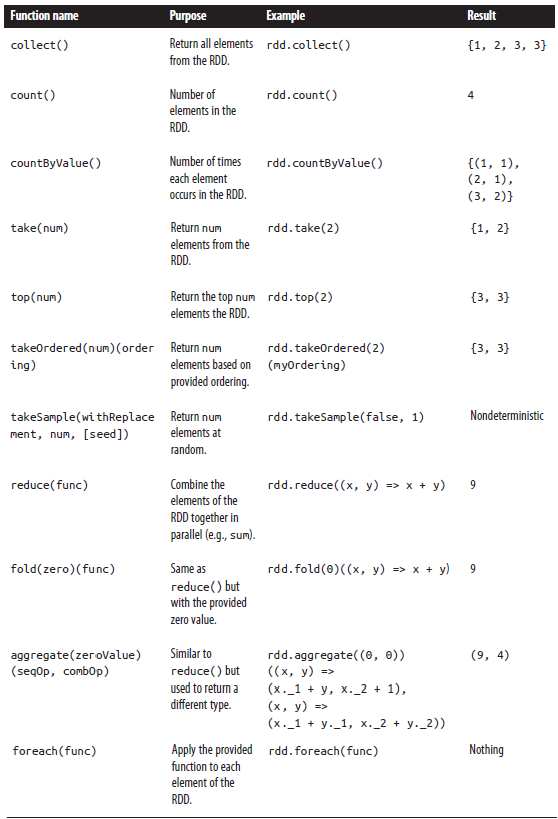

### Transformaciones en Spark

A continuación se define un listado de las transformaciones más comunes:
<br />-Para la columna __Result__ se calcula con un RDD con los valores {1, 2, 3, 3} en las operaciones unarias (map, flatMap, filter, distinct, sample) y para las binarias rdd={1, 2, 3} y other={3, 4, 5}.-

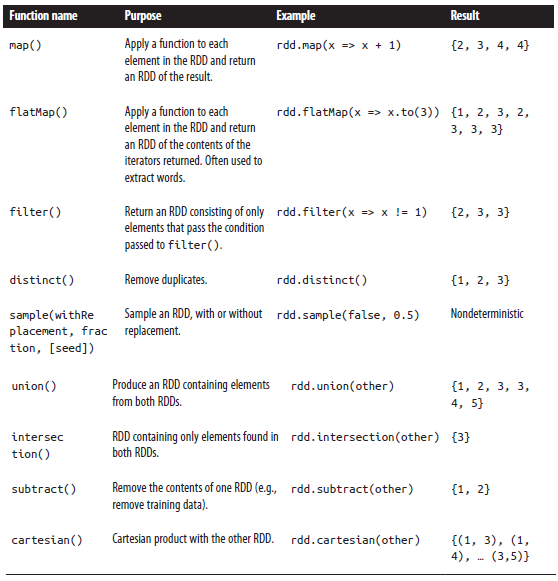

__Tip: ¿Cómo nos damos cuenta  si ejecutamos una transformación o una acción? Si la operación devuelve un RDD es transformación, de lo contrario es acción.__

Ahora que conocemos las RDD, las transformaciones y acciones, veamos como realizaríamos el _wordCount_ con Spark:

In [ ]:
# Separo en palabras
words = text_file.flatMap(lambda line: line.split(" "))

# Transformo a clave-valor
key_value = words.map(lambda word: (word, 1))

# Agrupo por clave
wordCounts = key_value.reduceByKey(lambda a,b:a +b)

# Muestro el primero
wordCounts.first()

# Muestro todos
for x in wordCounts.collect():
     print(x)

# Mostramos la cantidad
wordCounts.count()

('Este', 22)
('es', 47)
('un', 15)
('ejemplo', 3)
('de', 178)
('texto', 37)
('en', 94)
('castellano', 1)
('para', 39)
('contar', 4)
('palabras', 54)
('que', 14)
('se', 9)
('repiten.', 1)
('Los', 13)
('estudiantes', 4)
('pueden', 6)
('usar', 1)
('este', 19)
('practicar', 8)
('el', 51)
('procesamiento', 17)
('lenguaje', 3)
('natural.', 3)
('Cada', 14)
('línea', 12)
('archivo', 31)
('tiene', 5)
('algunas', 1)
('repetirse', 1)
('diferentes', 4)
('líneas.', 1)
('Contar', 11)
('puede', 14)
('ayudar', 3)
('a', 10)
('analizar', 3)
('la', 13)
('frecuencia', 8)
('términos', 1)
('documentos', 2)
('largos.', 1)
('Python', 16)
('una', 24)
('herramienta', 5)
('muy', 2)
('útil', 11)
('realizar', 1)
('tipo', 6)
('análisis', 41)
('texto.', 10)
('El', 14)
('repetidas', 4)
('común', 7)
('grandes', 8)
('volúmenes', 5)
('datos.', 15)
('En', 2)
('algunos', 1)
('contextos,', 1)
('saber', 1)
('cuántas', 2)
('veces', 3)
('aparece', 2)
('palabra', 3)
('ser', 9)
('valioso.', 1)
('Por', 1)
('ejemplo,', 1)
('los',

314

A continuación se muestra un código mejorado en el que se hace uso de

`re.findall(r'\b\w+\b', line.lower())`

Para buscar palabras usando una expresión regular (\b = límite de palabra, \w+ = secuencia de caracteres alfanuméricos).

Se ignoran por tanto los signos de puntuación como , . : ; ! ? "() automáticamente.

Además con `line.lower()` se convierte todo a minúsculas para que "Hola" y "hola" cuenten igual.

In [ ]:
import re

# 1. Separar en palabras limpiando signos de puntuación
words = text_file.flatMap(lambda line: re.findall(r'\b\w+\b', line.lower()))

# 2. Transformar a clave-valor
key_value = words.map(lambda word: (word, 1))

# 3. Agrupar y contar
wordCounts = key_value.reduceByKey(lambda a, b: a + b)

# 4. Mostrar el primero
print(wordCounts.first())

# 5. Mostrar todos
for x in wordCounts.collect():
    print(x)

# 6. Mostrar cuántas palabras únicas hay
print("Número de palabras únicas:", wordCounts.count())


('este', 41)
('es', 47)
('un', 16)
('ejemplo', 5)
('de', 178)
('texto', 49)
('en', 96)
('castellano', 1)
('para', 39)
('contar', 15)
('palabras', 59)
('que', 14)
('se', 9)
('repiten', 3)
('los', 19)
('estudiantes', 5)
('pueden', 6)
('usar', 1)
('practicar', 8)
('el', 65)
('procesamiento', 17)
('lenguaje', 5)
('natural', 3)
('cada', 17)
('línea', 12)
('archivo', 33)
('tiene', 5)
('algunas', 2)
('repetirse', 1)
('diferentes', 4)
('líneas', 2)
('puede', 14)
('ayudar', 3)
('a', 11)
('analizar', 3)
('la', 22)
('frecuencia', 9)
('términos', 2)
('documentos', 3)
('largos', 1)
('python', 34)
('una', 25)
('herramienta', 5)
('muy', 2)
('útil', 11)
('realizar', 1)
('tipo', 6)
('análisis', 41)
('repetidas', 4)
('común', 7)
('grandes', 9)
('volúmenes', 6)
('datos', 36)
('algunos', 1)
('contextos', 2)
('saber', 1)
('cuántas', 2)
('veces', 3)
('aparece', 2)
('palabra', 3)
('ser', 9)
('valioso', 1)
('por', 1)
('estudios', 2)
('literatura', 2)
('clave', 2)
('identificar', 1)
('temas', 3)
('principales'